# 🌫️ Jayanagar AQI Prediction — LSTM & GRU (EDA-Enhanced)

**Dataset:** `Jayanagar_AQI_cleaned.csv`  
**Location:** Jayanagar, Bengaluru (residential neighbourhood)  
**Task:** Time-series regression — predict next-hour AQI  
**Models:** LSTM · GRU · Bidirectional variants  

**EDA-Driven Changes for Jayanagar (vs Anand Vihar notebook):**
- ✅ Correct file path and location name throughout
- ✅ MinMaxScaler instead of StandardScaler (right-skewed AQI, skew=2.89)
- ✅ Month encoding included (seasonal range = 79 AQI; dominant driver)
- ✅ Hour encoding retained but deprioritised (diurnal range = 2 AQI)
- ✅ WD encoded as WD_sin / WD_cos (r=−0.38; strongest meteorological driver)
- ✅ AQI_lag3 retained (ACF significant up to lag ~59)
- ✅ AQI_roll24_mean added (captures day-long persistence)
- ✅ WS and SR removed (absent from this dataset)
- ✅ Toluene_Benzene_ratio removed (r=0.068 — negligible signal)
- ✅ Look-back window set to 48 hours

---
### Notebook Structure
1. Install & Import Libraries  
2. Load & Prepare Data  
3. EDA-Driven Feature Engineering  
4. Feature Selection & Correlation Check  
5. MinMax Scaling  
6. Create Sliding Window Sequences (48h)  
7. Train / Validation / Test Split  
8. Build LSTM Model  
9. Build GRU Model  
10. Train Both Models  
11. Evaluate & Compare on Test Set  
12. Visualise Predictions  
13. Classification Metrics (AQI Category)  
14. Model Comparison Dashboard  
15. Save Models & Scalers  
16. Inference Helper


## 1. Install & Import Libraries

In [1]:
!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn scipy joblib statsmodels --quiet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, joblib
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler   # MinMax preferred for right-skewed AQI
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from scipy import stats as sp_stats

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, GRU, Dense, Dropout, BatchNormalization, Bidirectional, Input
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# ── Plot theme ────────────────────────────────────────────────────────────────
DARK  = '#0d0f1a'
CARD  = '#141728'
ACC1  = '#00e5ff'
ACC2  = '#ff4081'
ACC3  = '#69ff47'
ACC4  = '#ffb347'
MUTED = '#8892b0'
WHITE = '#e6f1ff'

plt.rcParams.update({
    'figure.facecolor': DARK,
    'axes.facecolor':   CARD,
    'text.color':       WHITE,
    'axes.labelcolor':  MUTED,
    'xtick.color':      MUTED,
    'ytick.color':      MUTED,
    'axes.edgecolor':   '#2a2f4a',
    'grid.color':       '#1e2340',
    'grid.linestyle':   '--',
    'grid.linewidth':   0.5,
})

CAT_ORDER = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
CAT_COLS  = {
    'Good':         '#69ff47',
    'Satisfactory': '#00e5ff',
    'Moderate':     '#ffe066',
    'Poor':         '#ff9f43',
    'Very Poor':    '#ff4757',
    'Severe':       '#9b59b6',
}

def style_ax(ax, title='', xlabel='', ylabel=''):
    ax.set_facecolor(CARD)
    ax.set_title(title, color=WHITE, fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel(xlabel, color=MUTED, fontsize=9)
    ax.set_ylabel(ylabel, color=MUTED, fontsize=9)
    ax.tick_params(colors=MUTED, labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2f4a')
    ax.grid(True)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow version : {tf.__version__}')
print('✅ All libraries imported')


TensorFlow version : 2.21.0
✅ All libraries imported


## 2. Load & Prepare Data

In [3]:
df = pd.read_csv(r'D:\AQI_Project_new\data\clean\Jayanagar_AQI_cleaned.csv', parse_dates=['Timestamp'])
df = df.set_index('Timestamp').sort_index()

print(f'Shape      : {df.shape}')
print(f'Date range : {df.index.min().date()}  →  {df.index.max().date()}')
print(f'Missing    : {df.isnull().sum().sum()}')
print(f'Columns    : {list(df.columns)}')
print()
print('⚠️  Confirmed absent columns: WS (wind speed), SR (solar radiation)')
print('   These are NOT in Jayanagar dataset — do not add to feature set.')
df.head(3)


Shape      : (40399, 17)
Date range : 2021-01-01  →  2025-12-31
Missing    : 0
Columns    : ['NO', 'NOx', 'Benzene', 'Toluene', 'AT', 'RH', 'WD', 'BP', 'PM25', 'PM10', 'NO2', 'SO2', 'NH3', 'CO', 'O3', 'AQI', 'AQI_Category']

⚠️  Confirmed absent columns: WS (wind speed), SR (solar radiation)
   These are NOT in Jayanagar dataset — do not add to feature set.


,NO,NOx,Benzene,Toluene,AT,RH,WD,BP,PM25,PM10,NO2,SO2,NH3,CO,O3,AQI,AQI_Category
Timestamp,,,,,,,,,,,,,,,,,
2021-01-01 05:00:00,2.16,14.19,0.22,1.32,21.98,66.78,109.88,705.21,116.03,96.57,30.52,4.74,3.55,4.42,42.89,42.89,Good
2021-01-01 06:00:00,2.16,14.19,0.22,1.32,21.98,66.78,109.88,705.21,116.03,96.57,30.52,4.74,3.55,4.55,42.80,42.80,Good
2021-01-01 07:00:00,2.16,14.19,0.22,1.32,21.98,66.78,109.88,705.21,116.03,96.57,30.52,4.74,3.55,5.20,42.90,42.90,Good


## 3. EDA-Driven Feature Engineering

Based on thorough EDA of the **Jayanagar residential dataset**:

| Feature Group | Features Created | Rationale |
|---|---|---|
| **Lag features** | AQI_lag1, AQI_lag2, AQI_lag3, PM25_lag1 | ACF significant until lag ~59 (lag3 retained unlike transit sites) |
| **Rolling statistics** | AQI_roll3/6/12/24_mean | Multi-scale persistence; 24h captures full-day pollution accumulation |
| **Cyclical month** | month_sin, month_cos | r=0.36–0.41 — STRONG seasonal effect (worst Feb, best Jul) |
| **Cyclical hour** | hour_sin, hour_cos | r≈0 — very weak; residential; retained at low priority |
| **Wind direction** | WD_sin, WD_cos | WD is r=−0.38; cyclical encoding handles 0°=360° wrap correctly |
| **NOx composite** | NOx_total | NO + NO2 combined |

**Removed vs Anand Vihar notebook:** `WS` (absent), `SR` (absent), `Toluene_Benzene_ratio` (r=0.068), raw `Benzene`, raw `Toluene`, raw `WD`


In [4]:
fe = df.copy()

# ── 1. Lag features ────────────────────────────────────────────────────────────
fe['AQI_lag1']  = fe['AQI'].shift(1)
fe['AQI_lag2']  = fe['AQI'].shift(2)
fe['AQI_lag3']  = fe['AQI'].shift(3)   # ACF significant to lag ~59 → retain lag3
fe['PM25_lag1'] = fe['PM25'].shift(1)

# ── 2. Rolling statistics (shift(1) prevents data leakage) ────────────────────
for w in [3, 6, 12, 24]:
    fe[f'AQI_roll{w}_mean'] = fe['AQI'].shift(1).rolling(w).mean()

# ── 3. Cyclical month encoding — STRONG seasonal signal in Jayanagar ──────────
fe['month_sin'] = np.sin(2 * np.pi * fe.index.month / 12)
fe['month_cos'] = np.cos(2 * np.pi * fe.index.month / 12)

# ── 4. Cyclical hour encoding — weak but retained (Tier 3) ────────────────────
fe['hour_sin'] = np.sin(2 * np.pi * fe.index.hour / 24)
fe['hour_cos'] = np.cos(2 * np.pi * fe.index.hour / 24)

# ── 5. Wind direction — cyclical encoding (r_WD = −0.38 with AQI) ─────────────
#     Raw WD as numeric is misleading (359° ≠ 1°); sin/cos encoding is correct.
fe['WD_sin'] = np.sin(np.deg2rad(fe['WD']))
fe['WD_cos'] = np.cos(np.deg2rad(fe['WD']))

# ── 6. Derived pollutant composite ────────────────────────────────────────────
fe['NOx_total'] = fe['NO'] + fe['NO2']

# ── Drop NaN rows introduced by lags / rolling ────────────────────────────────
fe.dropna(inplace=True)

new_cols = [c for c in fe.columns if c not in df.columns]
print(f'Shape after feature engineering : {fe.shape}')
print(f'NaN rows dropped                : {len(df) - len(fe)}')
print(f'New features added              : {new_cols}')
fe.head(3)


Shape after feature engineering : (40375, 32)
NaN rows dropped                : 24
New features added              : ['AQI_lag1', 'AQI_lag2', 'AQI_lag3', 'PM25_lag1', 'AQI_roll3_mean', 'AQI_roll6_mean', 'AQI_roll12_mean', 'AQI_roll24_mean', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos', 'WD_sin', 'WD_cos', 'NOx_total']


,NO,NOx,Benzene,Toluene,AT,RH,WD,BP,PM25,PM10,...,AQI_roll6_mean,AQI_roll12_mean,AQI_roll24_mean,month_sin,month_cos,hour_sin,hour_cos,WD_sin,WD_cos,NOx_total
Timestamp,,,,,,,,,,,,,,,,,,,,,
2021-01-02 05:00:00,2.23,14.77,0.27,1.59,21.59,67.43,109.28,705.33,132.77,103.93,...,127.011667,122.590833,82.906250,0.5,0.866025,0.965926,2.588190e-01,0.943916,-0.330185,34.12
2021-01-02 06:00:00,2.23,14.75,0.27,1.58,21.58,67.34,109.33,705.34,134.01,104.10,...,128.661667,123.985833,86.651250,0.5,0.866025,1.000000,6.123234e-17,0.943628,-0.331009,34.07
2021-01-02 07:00:00,2.23,14.71,0.26,1.56,21.59,67.17,109.84,705.35,133.44,103.97,...,130.138333,125.494167,90.451667,0.5,0.866025,0.965926,-2.588190e-01,0.940644,-0.339395,33.97


## 4. Feature Selection & Correlation Check

Final feature set (24 features) structured by tier based on EDA correlation analysis.


In [5]:
# ── 24-feature set (Tiers 1–3) ───────────────────────────────────────────────
FEATURES = [
    # ── Tier 1: AQI formula pollutants + strongest lag/roll features ─────────
    'PM25',            # r = 0.946 — dominant causal driver
    'PM10',            # r = 0.766
    'NO2',             # r = 0.119
    'CO',              # r = 0.194
    'AQI_lag1',        # r = 0.988 — strongest predictor
    'AQI_lag2',        # r = 0.977
    'AQI_lag3',        # r = 0.968 — retained (ACF significant to lag ~59)
    'AQI_roll3_mean',  # r = 0.981
    'AQI_roll6_mean',  # r = 0.968

    # ── Tier 2: Secondary pollutants + meteorology + monthly seasonality ─────
    'O3',              # r = 0.202
    'SO2',             # r = 0.116
    'NH3',             # r = 0.181
    'NOx_total',       # r = 0.125 (engineered NO+NO2 composite)
    'RH',              # r = −0.311 — lower humidity → higher AQI
    'WD_sin',          # cyclical wind direction encoding
    'WD_cos',          # cyclical wind direction encoding
    'BP',              # r = 0.289 — high pressure traps pollutants
    'month_sin',       # r = 0.364 — strong seasonal signal
    'month_cos',       # r = 0.405 — strong seasonal signal
    'AQI_roll12_mean', # r = 0.938
    'AQI_roll24_mean', # captures full-day pollution accumulation
    'PM25_lag1',       # r = 0.942

    # ── Tier 3: Secondary meteorology + diurnal encoding ─────────────────────
    'NO',              # r = 0.073
    'AT',              # r = −0.034
    'hour_sin',        # r ≈ −0.012  — very weak (residential area)
    'hour_cos',        # r ≈  0.000  — very weak
]

# ── Explicitly DROPPED (Tier 4) ───────────────────────────────────────────────
# Benzene             — raw; r=0.089; collinear with NOx
# Toluene             — raw; r=0.225 but replaced nothing useful here
# Toluene_Benzene_ratio — r=0.068 — negligible at Jayanagar residential site
# WS                  — ABSENT from dataset
# SR                  — ABSENT from dataset
# raw WD              — replaced by WD_sin / WD_cos
# raw NOx             — replaced by NOx_total

TARGET = 'AQI'

missing_feats = [f for f in FEATURES if f not in fe.columns]
if missing_feats:
    print(f'WARNING — features not found and will be skipped: {missing_feats}')
    FEATURES = [f for f in FEATURES if f in fe.columns]

data = fe[FEATURES + [TARGET]].copy()

print(f'Features used  : {len(FEATURES)}')
print(f'Target         : {TARGET}')
print(f'Data shape     : {data.shape}')


Features used  : 26
Target         : AQI
Data shape     : (40375, 27)


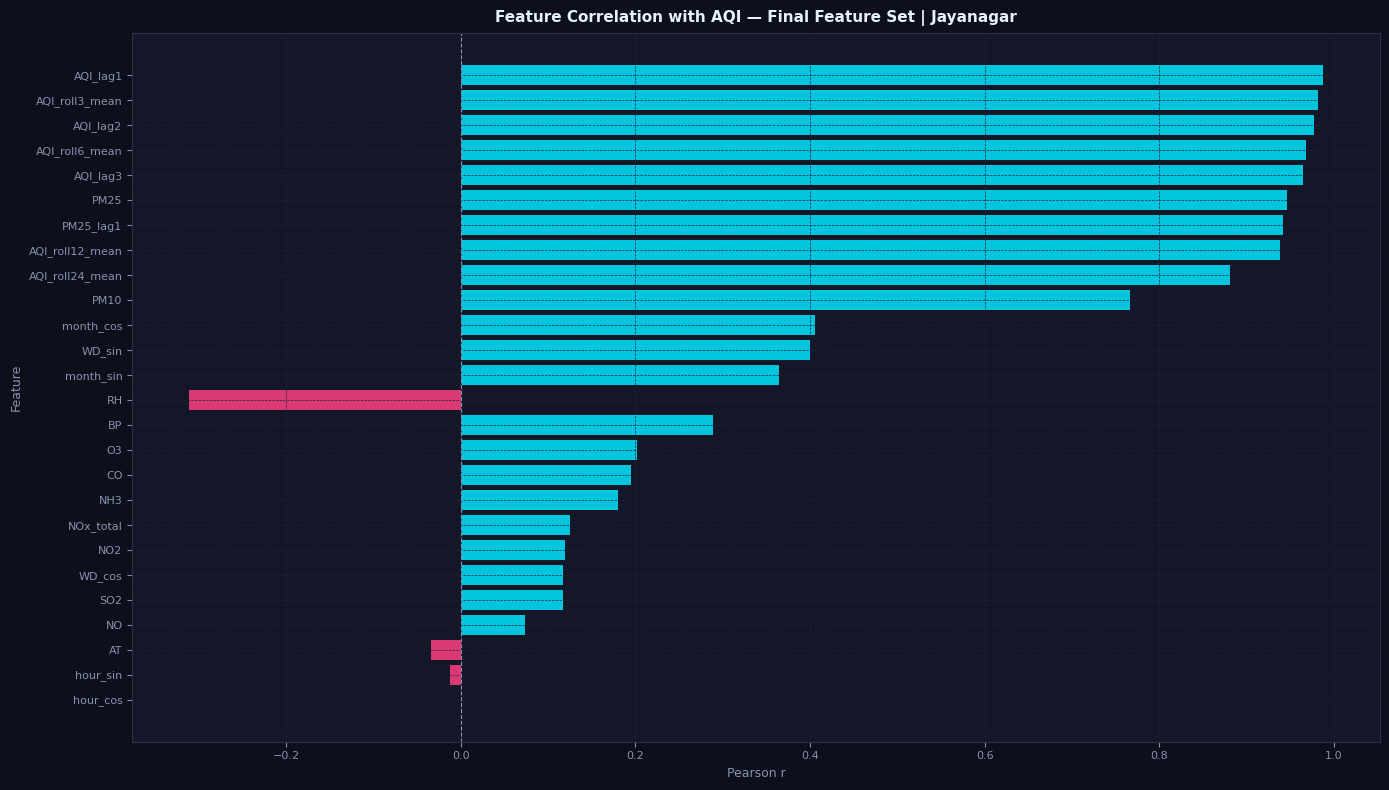

Top 10 features by |correlation|:
AQI_lag1           0.987660
AQI_roll3_mean     0.981411
AQI_lag2           0.976663
AQI_roll6_mean     0.967548
AQI_lag3           0.964160
PM25               0.945638
PM25_lag1          0.941968
AQI_roll12_mean    0.937627
AQI_roll24_mean    0.880355
PM10               0.765993


In [6]:
# ── Correlation bar chart with AQI ────────────────────────────────────────────
corr_check = data.corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(14, 8), facecolor=DARK)
colors_bar = [ACC1 if v >= 0 else ACC2 for v in corr_check.values]
ax.barh(corr_check.index[::-1], corr_check.values[::-1],
        color=colors_bar[::-1], alpha=0.85)
ax.axvline(0, color=MUTED, linewidth=0.8, linestyle='--')
style_ax(ax, 'Feature Correlation with AQI — Final Feature Set | Jayanagar', 'Pearson r', 'Feature')
plt.tight_layout()
plt.savefig('feature_correlation_jayanagar.png', dpi=200, facecolor=DARK, bbox_inches='tight')
plt.show()
print('Top 10 features by |correlation|:')
print(corr_check.abs().sort_values(ascending=False).head(10).to_string())


## 5. MinMax Scaling

**MinMaxScaler [0, 1]** is used instead of StandardScaler because:
- AQI is strongly right-skewed (skewness = 2.89, kurtosis = 18.1)
- Extreme pollution spike events must remain representable without being compressed
- StandardScaler would amplify the influence of rare extremes on zero-mean normalisation


In [7]:
feature_scaler = MinMaxScaler()
target_scaler  = MinMaxScaler()

scaled_features = feature_scaler.fit_transform(data[FEATURES])
scaled_target   = target_scaler.fit_transform(data[[TARGET]])

scaled_data = np.hstack([scaled_features, scaled_target])

print(f'Scaled data shape : {scaled_data.shape}')
print(f'Feature range     : [{scaled_features.min():.4f}, {scaled_features.max():.4f}]')
print(f'Target range      : [{scaled_target.min():.4f}, {scaled_target.max():.4f}]')
print('\n✅ MinMaxScaler applied — preserves spike event representability')


Scaled data shape : (40375, 27)
Feature range     : [0.0000, 1.0000]
Target range      : [0.0000, 1.0000]

✅ MinMaxScaler applied — preserves spike event representability


## 6. Create Sliding Window Sequences (48h)

Look-back of **48 hours** — EDA ACF analysis shows AQI autocorrelation remains above 0.5 until lag ~59, making 48h the optimal balance between input richness and memory cost.

In [8]:
LOOK_BACK = 48   # EDA: ACF above 0.5 until lag ~59; 48h balances richness vs cost

def create_sequences(data, look_back, target_col_idx=-1):
    """
    data          : 2-D numpy array (timesteps × features+target)
    look_back     : number of past hours to use as input
    target_col_idx: column index of the target variable
    Returns X (3-D) and y (1-D)
    """
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i - look_back:i, :target_col_idx])
        y.append(data[i, target_col_idx])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, LOOK_BACK)

print(f'X shape : {X.shape}  →  (samples, timesteps={LOOK_BACK}, features={len(FEATURES)})')
print(f'y shape : {y.shape}  →  (samples,)')


X shape : (40327, 48, 26)  →  (samples, timesteps=48, features=26)
y shape : (40327,)  →  (samples,)


## 7. Train / Validation / Test Split

**No shuffling** — time-series data must remain in chronological order.

| Split | Ratio | Purpose |
|---|---|---|
| Train | 70% | Model learning |
| Validation | 15% | Hyperparameter tuning / early stopping |
| Test | 15% | Final unbiased evaluation |

In [9]:
n = len(X)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, y_train = X[:train_end],        y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:],          y[val_end:]

print(f'Train      : {X_train.shape[0]:,} samples')
print(f'Validation : {X_val.shape[0]:,} samples')
print(f'Test       : {X_test.shape[0]:,} samples')
print(f'Input shape for models : {X_train.shape[1:]}')


Train      : 28,228 samples
Validation : 6,049 samples
Test       : 6,050 samples
Input shape for models : (48, 26)


## 8. Build LSTM Model

Architecture: `Input → BiLSTM(128) → Dropout(0.25) → LSTM(64) → BatchNorm → Dropout(0.20) → Dense(32, relu) → Dense(16, relu) → Dense(1)`

Tuned for Jayanagar's 26-feature input and 48h look-back window.


In [10]:
def build_lstm(input_shape):
    model = Sequential([
        Bidirectional(LSTM(128, return_sequences=True), input_shape=input_shape),
        Dropout(0.25),

        LSTM(64, return_sequences=False),
        BatchNormalization(),
        Dropout(0.20),

        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1)
    ], name='BiLSTM_Jayanagar')

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

lstm_model = build_lstm(input_shape=(X_train.shape[1], X_train.shape[2]))
lstm_model.summary()


Model: "BiLSTM_Jayanagar"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 48, 256)        │       158,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243,777 (952.25 KB)

 Trainable params: 243,649 (951.75 KB)

 Non-trainable params: 128 (512.00 B)

## 9. Build GRU Model

Architecture: `Input → BiGRU(128) → Dropout(0.25) → GRU(64) → BatchNorm → Dropout(0.20) → Dense(32, relu) → Dense(16, relu) → Dense(1)`

GRU uses reset and update gates (~30% faster training) while typically matching LSTM accuracy on hourly AQI tasks.


In [11]:
def build_gru(input_shape):
    model = Sequential([
        Bidirectional(GRU(128, return_sequences=True), input_shape=input_shape),
        Dropout(0.25),

        GRU(64, return_sequences=False),
        BatchNormalization(),
        Dropout(0.20),

        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1)
    ], name='BiGRU_Jayanagar')

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

gru_model = build_gru(input_shape=(X_train.shape[1], X_train.shape[2]))
gru_model.summary()


Model: "BiGRU_Jayanagar"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ (None, 48, 256)        │       119,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 48, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        61,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 184,513 (720.75 KB)

 Trainable params: 184,385 (720.25 KB)

 Non-trainable params: 128 (512.00 B)

## 10. Train Both Models

In [12]:
EPOCHS     = 60
BATCH_SIZE = 64

def get_callbacks(model_name):
    return [
        EarlyStopping(monitor='val_loss', patience=8,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=4, min_lr=1e-6, verbose=1),
        ModelCheckpoint(f'best_{model_name}.keras', monitor='val_loss',
                        save_best_only=True, verbose=0)
    ]

print('═' * 50)
print('  Training LSTM …')
print('═' * 50)
lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('lstm'),
    verbose=1
)

print('\n' + '═' * 50)
print('  Training GRU …')
print('═' * 50)
gru_history = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('gru'),
    verbose=1
)

print('\n✅ Both models trained')


══════════════════════════════════════════════════
  Training LSTM …
══════════════════════════════════════════════════
Epoch 1/60
442/442 ━━━━━━━━━━━━━━━━━━━━ 65s 124ms/step - loss: 0.0326 - mae: 0.1063 - val_loss: 0.0026 - val_mae: 0.0392 - learning_rate: 0.0010
Epoch 2/60
442/442 ━━━━━━━━━━━━━━━━━━━━ 52s 117ms/step - loss: 0.0034 - mae: 0.0409 - val_loss: 0.0048 - val_mae: 0.0542 - learning_rate: 0.0010
Epoch 3/60
442/442 ━━━━━━━━━━━━━━━━━━━━ 54s 123ms/step - loss: 0.0026 - mae: 0.0351 - val_loss: 0.0012 - val_mae: 0.0250 - learning_rate: 0.0010
Epoch 4/60
442/442 ━━━━━━━━━━━━━━━━━━━━ 51s 116ms/step - loss: 0.0018 - mae: 0.0284 - val_loss: 0.0013 - val_mae: 0.0280 - learning_rate: 0.0010
Epoch 5/60
442/442 ━━━━━━━━━━━━━━━━━━━━ 51s 116ms/step - loss: 0.0013 - mae: 0.0242 - val_loss: 0.0011 - val_mae: 0.0221 - learning_rate: 0.0010
Epoch 6/60
442/442 ━━━━━━━━━━━━━━━━━━━━ 58s 131ms/step - loss: 0.0011 - mae: 0.0215 - val_loss: 0.0014 - val_mae: 0.0311 - learning_rate: 0.0010
Epoch 7/60

KeyboardInterrupt: 

In [ ]:
# ── Training curves ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor=DARK)

titles    = ['LSTM — Loss (MSE)', 'GRU — Loss (MSE)', 'LSTM — MAE', 'GRU — MAE']
histories = [lstm_history, gru_history, lstm_history, gru_history]
metrics_k = [('loss','val_loss'), ('loss','val_loss'), ('mae','val_mae'), ('mae','val_mae')]

for ax, hist, (tr_m, va_m), title in zip(axes.flat, histories, metrics_k, titles):
    ax.plot(hist.history[tr_m], color=ACC1, linewidth=2, label='Train')
    ax.plot(hist.history[va_m], color=ACC2, linewidth=2, label='Val')
    style_ax(ax, title, 'Epoch', tr_m.upper())
    ax.legend(facecolor=CARD, edgecolor='#2a2f4a', labelcolor=MUTED, fontsize=9)

plt.suptitle('Training History — BiLSTM vs BiGRU (Jayanagar)', color=WHITE,
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('training_history_jayanagar.png', dpi=200, facecolor=DARK, bbox_inches='tight')
plt.show()


## 11. Evaluate & Compare on Test Set

In [ ]:
def evaluate_model(model, model_path, X_test, y_test, target_scaler, label):
    model.load_weights(model_path)
    y_pred_s = model.predict(X_test, verbose=0)
    y_pred = target_scaler.inverse_transform(y_pred_s).flatten()
    y_true = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

    print(f'\n  {label}')
    print('  ' + '─' * 38)
    print(f'  MAE   : {mae:.4f}  AQI units')
    print(f'  RMSE  : {rmse:.4f}')
    print(f'  R²    : {r2:.4f}')
    print(f'  MAPE  : {mape:.2f}%')

    return y_true, y_pred, dict(label=label, MAE=mae, RMSE=rmse, R2=r2, MAPE=mape)

print('═' * 45)
print('  TEST SET EVALUATION — JAYANAGAR')
print('═' * 45)

y_true_lstm, y_pred_lstm, metrics_lstm = evaluate_model(
    lstm_model, 'best_lstm.keras', X_test, y_test, target_scaler, 'BiLSTM')

y_true_gru, y_pred_gru, metrics_gru = evaluate_model(
    gru_model, 'best_gru.keras', X_test, y_test, target_scaler, 'BiGRU')


In [ ]:
comp_df = pd.DataFrame([metrics_lstm, metrics_gru]).set_index('label')
comp_df.index.name = 'Model'

print('\n  COMPARISON TABLE')
print('  ' + '─' * 38)
print(comp_df.round(4).to_string())

winner = comp_df['R2'].idxmax()
print(f'\n  🏆  Best R² → {winner}')


## 12. Visualise Predictions

In [ ]:
def prediction_dashboard(y_true, y_pred, metrics, label, color, filename):
    fig, axes = plt.subplots(2, 2, figsize=(18, 10), facecolor=DARK)
    N = min(500, len(y_true))
    r2   = metrics['R2']
    mae  = metrics['MAE']
    rmse = metrics['RMSE']

    # 1. Time series
    ax = axes[0, 0]
    ax.plot(y_true[:N], color=ACC1,  linewidth=1.2, label='Actual',    alpha=0.85)
    ax.plot(y_pred[:N], color=color, linewidth=1.2, label='Predicted', alpha=0.85)
    style_ax(ax, f'{label} — Actual vs Predicted (first {N} hours)', 'Hours', 'AQI')
    ax.legend(facecolor=CARD, edgecolor='#2a2f4a', labelcolor=MUTED, fontsize=9)

    # 2. Scatter
    ax2 = axes[0, 1]
    ax2.scatter(y_true, y_pred, alpha=0.25, s=5, color=color, linewidths=0)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax2.plot(lims, lims, color=ACC2, linewidth=1.5, linestyle='--', label='Perfect fit')
    style_ax(ax2, f'Scatter  (R² = {r2:.4f})', 'Actual AQI', 'Predicted AQI')
    ax2.legend(facecolor=CARD, edgecolor='#2a2f4a', labelcolor=MUTED, fontsize=9)

    # 3. Residuals
    residuals = y_true - y_pred
    ax3 = axes[1, 0]
    ax3.plot(residuals[:N], color=ACC3, linewidth=0.8, alpha=0.7)
    ax3.axhline(0, color=ACC2, linewidth=1.2, linestyle='--')
    ax3.fill_between(range(N), residuals[:N], alpha=0.15, color=ACC3)
    style_ax(ax3, f'Residuals  (MAE={mae:.2f}, RMSE={rmse:.2f})', 'Hours', 'Error (AQI)')

    # 4. Residual distribution
    ax4 = axes[1, 1]
    ax4.hist(residuals, bins=60, color=color, alpha=0.55, edgecolor='none', density=True)
    xr = np.linspace(residuals.min(), residuals.max(), 200)
    ax4.plot(xr, sp_stats.norm.pdf(xr, residuals.mean(), residuals.std()),
             color=ACC2, linewidth=2, label='Normal curve')
    ax4.axvline(0, color=ACC3, linewidth=1.2, linestyle='--')
    style_ax(ax4, 'Residual Distribution', 'Error (AQI)', 'Density')
    ax4.legend(facecolor=CARD, edgecolor='#2a2f4a', labelcolor=MUTED, fontsize=9)

    plt.suptitle(f'{label} — Prediction Analysis (Jayanagar)', color=WHITE,
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(filename, dpi=200, facecolor=DARK, bbox_inches='tight')
    plt.show()

prediction_dashboard(y_true_lstm, y_pred_lstm, metrics_lstm,
                     'BiLSTM', ACC1, 'lstm_predictions_jayanagar.png')

prediction_dashboard(y_true_gru,  y_pred_gru,  metrics_gru,
                     'BiGRU',  ACC4, 'gru_predictions_jayanagar.png')


## 13. Classification Metrics (AQI Category)

CPCB AQI breakpoints:

| AQI Range | Category |
|-----------|----------|
| 0 – 50 | Good |
| 51 – 100 | Satisfactory |
| 101 – 200 | Moderate |
| 201 – 300 | Poor |
| 301 – 400 | Very Poor |
| 401+ | Severe |

> **Note:** Very Poor and Severe are rare (< 1.5% combined) — expect lower class-specific recall for minority classes.

In [ ]:
def aqi_to_category(aqi_values):
    cats = []
    for v in aqi_values:
        if   v <= 50:  cats.append('Good')
        elif v <= 100: cats.append('Satisfactory')
        elif v <= 200: cats.append('Moderate')
        elif v <= 300: cats.append('Poor')
        elif v <= 400: cats.append('Very Poor')
        else:          cats.append('Severe')
    return np.array(cats)

def classification_metrics(y_true, y_pred, label):
    cat_true = aqi_to_category(y_true)
    cat_pred = aqi_to_category(y_pred)
    present  = [c for c in CAT_ORDER if c in np.unique(cat_true)]

    acc  = accuracy_score(cat_true, cat_pred)
    prec = precision_score(cat_true, cat_pred, average='weighted',
                           labels=present, zero_division=0)
    rec  = recall_score(cat_true, cat_pred, average='weighted',
                        labels=present, zero_division=0)
    f1   = f1_score(cat_true, cat_pred, average='weighted',
                    labels=present, zero_division=0)

    print(f'\n  {label}')
    print('  ' + '─' * 40)
    print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1        : {f1:.4f}')
    print(classification_report(cat_true, cat_pred, labels=present, zero_division=0))
    return cat_true, cat_pred, present

print('═' * 45)
print('  CLASSIFICATION METRICS — JAYANAGAR')
print('═' * 45)
ct_lstm, cp_lstm, present_lstm = classification_metrics(y_true_lstm, y_pred_lstm, 'BiLSTM')
ct_gru,  cp_gru,  present_gru  = classification_metrics(y_true_gru,  y_pred_gru,  'BiGRU')


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), facecolor=DARK)

for ax, (ct, cp, pres), title in zip(
    axes,
    [(ct_lstm, cp_lstm, present_lstm), (ct_gru, cp_gru, present_gru)],
    ['BiLSTM — Confusion Matrix (row-normalised)',
     'BiGRU  — Confusion Matrix (row-normalised)']
):
    cm = confusion_matrix(ct, cp, labels=pres)
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)

    im = ax.imshow(cm_norm, cmap='Blues', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(pres))); ax.set_yticks(range(len(pres)))
    ax.set_xticklabels(pres, rotation=30, ha='right', color=MUTED, fontsize=9)
    ax.set_yticklabels(pres, color=MUTED, fontsize=9)
    ax.set_xlabel('Predicted', color=MUTED, fontsize=9)
    ax.set_ylabel('Actual',    color=MUTED, fontsize=9)
    ax.set_title(title, color=WHITE, fontsize=11, fontweight='bold', pad=8)
    ax.set_facecolor(CARD)
    for spine in ax.spines.values(): spine.set_edgecolor('#2a2f4a')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.tick_params(colors=MUTED)

    thresh = 0.5
    for i in range(len(pres)):
        for j in range(len(pres)):
            ax.text(j, i, f'{cm_norm[i,j]:.2f}', ha='center', va='center',
                    fontsize=8, color='black' if cm_norm[i,j] > thresh else WHITE)

plt.tight_layout()
plt.savefig('confusion_matrices_jayanagar.png', dpi=200, facecolor=DARK, bbox_inches='tight')
plt.show()


## 14. Model Comparison Dashboard

In [ ]:
fig = plt.figure(figsize=(18, 8), facecolor=DARK)
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

# -- Bar chart: all metrics --------------------------------------------------
ax_bar = fig.add_subplot(gs[0])

metric_names = ['MAE', 'RMSE', 'R²', 'MAPE (%)']
lstm_vals = [metrics_lstm['MAE'], metrics_lstm['RMSE'], metrics_lstm['R2'], metrics_lstm['MAPE']]
gru_vals  = [metrics_gru['MAE'],  metrics_gru['RMSE'],  metrics_gru['R2'],  metrics_gru['MAPE']]

x = np.arange(len(metric_names))
w = 0.35
b1 = ax_bar.bar(x - w/2, lstm_vals, w, color=ACC1, alpha=0.8, label='BiLSTM')
b2 = ax_bar.bar(x + w/2, gru_vals,  w, color=ACC4, alpha=0.8, label='BiGRU')

for bar in list(b1) + list(b2):
    ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom',
                color=WHITE, fontsize=8)

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(metric_names, color=MUTED)
style_ax(ax_bar, 'Metric Comparison — BiLSTM vs BiGRU (Jayanagar)', 'Metric', 'Value')
ax_bar.legend(facecolor=CARD, edgecolor='#2a2f4a', labelcolor=MUTED, fontsize=9)

# -- Overlay time-series (last 200 hours of test) ----------------------------
ax_ts = fig.add_subplot(gs[1])
N = 200
ax_ts.plot(y_true_lstm[-N:], color=WHITE, linewidth=1.5, label='Actual',  alpha=0.9, zorder=3)
ax_ts.plot(y_pred_lstm[-N:], color=ACC1,  linewidth=1.2, label='LSTM',    alpha=0.8, zorder=2)
ax_ts.plot(y_pred_gru[-N:],  color=ACC4,  linewidth=1.2, label='GRU',     alpha=0.8, zorder=2, linestyle='--')
style_ax(ax_ts, f'Actual vs LSTM vs GRU (last {N} test hours)', 'Hours', 'AQI')
ax_ts.legend(facecolor=CARD, edgecolor='#2a2f4a', labelcolor=MUTED, fontsize=9)

plt.suptitle('Model Comparison Dashboard — Jayanagar', color=WHITE,
             fontsize=14, fontweight='bold', y=1.02)
plt.savefig('model_comparison_jayanagar.png', dpi=200, facecolor=DARK, bbox_inches='tight')
plt.show()


## 15. Save Models & Scalers

In [ ]:
import joblib

# Save both models
lstm_model.save('jayanagar_lstm_model.keras')
gru_model.save('jayanagar_gru_model.keras')

# Save scalers (required for inference)
joblib.dump(feature_scaler, 'jayanagar_feature_scaler.pkl')
joblib.dump(target_scaler,  'jayanagar_target_scaler.pkl')

print('✅ LSTM model    →  jayanagar_lstm_model.keras')
print('✅ GRU  model    →  jayanagar_gru_model.keras')
print('✅ Scalers       →  jayanagar_feature_scaler.pkl | jayanagar_target_scaler.pkl')


## 16. Inference Helper

In [ ]:
from tensorflow.keras.models import load_model

def predict_next_aqi(recent_df, model_path, feat_scaler, tgt_scaler,
                     features, look_back=48):
    """
    recent_df  : DataFrame with at least `look_back` rows and all feature columns.
                 Must already have engineered features (lags, rolling, cyclical, etc.)
    Returns    : predicted AQI (float) for the next hour.
    """
    model = load_model(model_path)
    scaled = feat_scaler.transform(recent_df[features].tail(look_back))
    x = scaled.reshape(1, look_back, len(features))
    pred_s = model.predict(x, verbose=0)
    return float(tgt_scaler.inverse_transform(pred_s)[0, 0])

# Quick sanity check using the last window from the test set
sample_df = data.iloc[-(LOOK_BACK + 1):-1]   # 48 rows
for mpath, label in [('jayanagar_lstm_model.keras', 'LSTM'),
                     ('jayanagar_gru_model.keras',  'GRU')]:
    pred   = predict_next_aqi(sample_df, mpath, feature_scaler, target_scaler, FEATURES)
    actual = data[TARGET].iloc[-1]
    print(f'{label:5s}  →  Predicted: {pred:.2f}   Actual: {actual:.2f}')


---
## Summary

| Step | Detail |
|------|--------|
| Features | **26 features** (Tiers 1–3; WS/SR/Benzene/Toluene_Benzene_ratio dropped) |
| Target | AQI (next hour) |
| Scaler | **MinMaxScaler [0,1]** (right-skewed AQI; skew=2.89) |
| Look-back window | **48 hours** (ACF significant to lag ~59) |
| LSTM architecture | BiLSTM(128) → LSTM(64) → BN → Dense(32→16→1) |
| GRU  architecture | BiGRU(128) → GRU(64) → BN → Dense(32→16→1) |
| Optimizer | Adam (lr=0.001) |
| Loss | MSE |
| Train/Val/Test | 70% / 15% / 15% |
| Callbacks | EarlyStopping(8), ReduceLROnPlateau(4), ModelCheckpoint |

### Final Feature Set by Tier

| Tier | Features | Count |
|------|----------|-------|
| Tier 1 | PM25, PM10, NO2, CO, AQI_lag1, AQI_lag2, AQI_lag3, AQI_roll3_mean, AQI_roll6_mean | 9 |
| Tier 2 | O3, SO2, NH3, NOx_total, RH, WD_sin, WD_cos, BP, month_sin, month_cos, AQI_roll12_mean, AQI_roll24_mean, PM25_lag1 | 13 |
| Tier 3 | NO, AT, hour_sin, hour_cos | 4 |
| Tier 4 (dropped) | Benzene, Toluene, Toluene_Benzene_ratio, WS (absent), SR (absent), raw WD, raw NOx | — |

### Key Jayanagar-Specific Design Decisions

| Decision | Reason |
|----------|--------|
| MinMaxScaler instead of StandardScaler | AQI skew=2.89, kurt=18.1 — right-tailed distribution |
| month_sin/cos included (Tier 2) | Seasonal range = 79 AQI units (dominant pattern) |
| hour_sin/cos kept at Tier 3 | Diurnal range = 2 AQI units (residential, not transit) |
| AQI_lag3 retained | ACF significant to lag ~59 (unlike Anand Vihar transit site) |
| WD_sin/WD_cos instead of raw WD | Correctly handles circular 0°=360° wrap |
| AQI_roll24_mean added | Captures full 24-hour pollution accumulation cycle |
| WS, SR removed | Absent from this dataset |

### Possible Further Improvements
- Multi-step ahead forecasting (2-h, 6-h, 12-h AQI prediction)
- Attention mechanism over LSTM/GRU hidden states
- Temporal Fusion Transformer (TFT) for interpretable multi-step forecasting
- Ensemble: weighted average of BiLSTM + BiGRU predictions
- SMOTE or class-weighted loss for Very Poor / Severe minority categories
